In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Impact_Of_Fuelprices - Form Responses.csv to Impact_Of_Fuelprices - Form Responses.csv


In [6]:
df = pd.read_csv('Impact_Of_Fuelprices - Form Responses.csv')
df.head()


,Timestamp,Gender,Age group,Which fuel grade do you most commonly use?,2.Approximately how many kilometers do you drive in a typical week?,3. Roughly how much do you spend on fuel per month?,"4.How much of a financial burden do you consider current fuel prices to be? (1 = no burden at all, 5 = very significant burden)",5.Have recent fuel price increases in Egypt changed any of your driving habits?
0,4/5/2026 23:02:50,Male,18-20,electric charging,More than 350 km,0.0,1,No change at all
1,4/5/2026 23:46:39,Female,18-20,Benzeen 92,50-100 km,2800.0,3,No change at all
2,4/6/2026 0:28:36,Male,18-20,Benzeen 92,100-200 km,3000.0,5,I share rides more often
3,4/6/2026 9:22:00,Male,18-20,Benzeen 95,Less than 50 km,1000.0,3,No change at all
4,4/6/2026 9:27:14,Male,21-23,Benzeen 95,100-200 km,1600.0,5,I drive shorter distances when possible


In [ ]:
# check data size
df.shape

(54, 8)

In [ ]:
# check data type
df.dtypes

,0
Timestamp,object
Gender,object
Age group,object
1.Which fuel grade do you most commonly use?,object
2.Approximately how many kilometers do you drive in a typical week?,object
3. Roughly how much do you spend on fuel per month?,float64
"4.How much of a financial burden do you consider current fuel prices to be? (1 = no burden at all, 5 = very significant burden)",int64
5.Have recent fuel price increases in Egypt changed any of your driving habits?,object


In [ ]:
# Count how many missing data
df.isnull().sum()

,0
Timestamp,0
Gender,0
Age group,0
1.Which fuel grade do you most commonly use?,0
2.Approximately how many kilometers do you drive in a typical week?,0
3. Roughly how much do you spend on fuel per month?,5
"4.How much of a financial burden do you consider current fuel prices to be? (1 = no burden at all, 5 = very significant burden)",0
5.Have recent fuel price increases in Egypt changed any of your driving habits?,0


In [ ]:
# since the data is important in our analysis, we decided to handle the missing data by filling them with the median
median = df['3. Roughly how much do you spend on fuel per month?'].median()
df['3. Roughly how much do you spend on fuel per month?'].fillna(median, inplace=True)
# inplace =True to change the actual csv file and not a copy

/tmp/ipykernel_14103/2292784656.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['3. Roughly how much do you spend on fuel per month?'].fillna(median, inplace=True)


In [ ]:
# check if it changed
df.isnull().sum()

,0
Timestamp,0
Gender,0
Age group,0
1.Which fuel grade do you most commonly use?,0
2.Approximately how many kilometers do you drive in a typical week?,0
3. Roughly how much do you spend on fuel per month?,0
"4.How much of a financial burden do you consider current fuel prices to be? (1 = no burden at all, 5 = very significant burden)",0
5.Have recent fuel price increases in Egypt changed any of your driving habits?,0


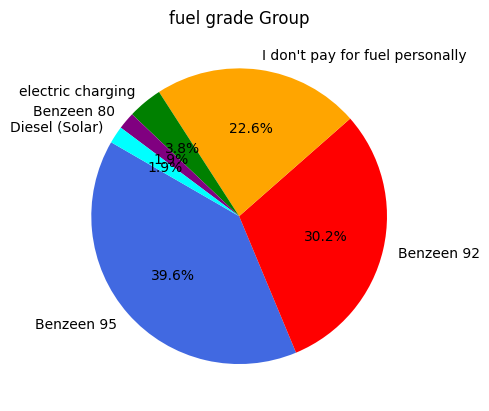

In [ ]:
# show most common used fuel grades
fuelGrades = df['1.Which fuel grade do you most commonly use?'].value_counts()
plt.pie(fuelGrades, labels=fuelGrades.index, autopct='%1.1f%%', colors=['royalblue', 'red', 'orange', 'green', 'purple', 'cyan'], startangle=150)
plt.title('fuel grade Group')
plt.savefig('fuel grade.png')
plt.show()

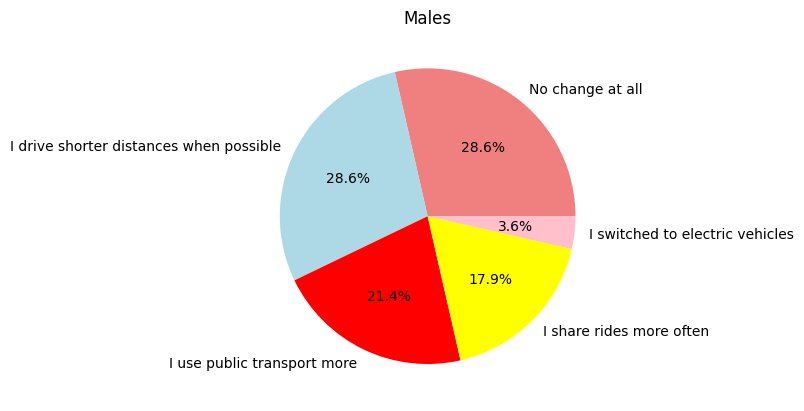

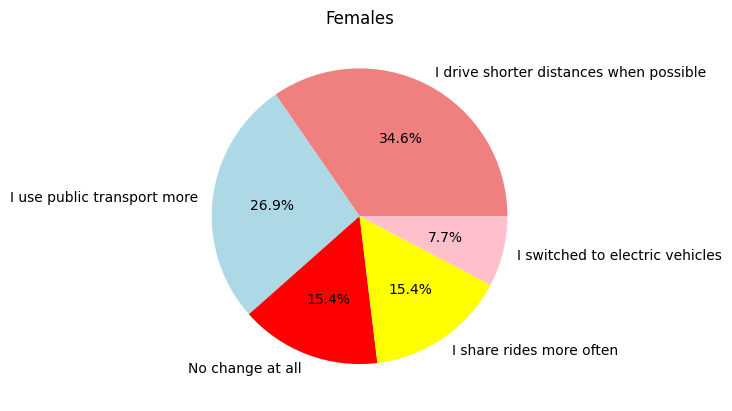

In [ ]:
# is gender related to driving habits?
male_counts = df[df['Gender'] == 'Male']['5.Have recent fuel price increases in Egypt changed any of your driving habits?'].value_counts()
plt.pie(male_counts, labels=male_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'red', 'yellow','pink'])
plt.title('Males')
plt.savefig('male.png')
plt.show()

female_counts = df[df['Gender'] == 'Female']['5.Have recent fuel price increases in Egypt changed any of your driving habits?'].value_counts()
plt.pie(female_counts, labels=female_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'red', 'yellow','pink'])
plt.title('Females')
plt.savefig('female.png')
plt.show()

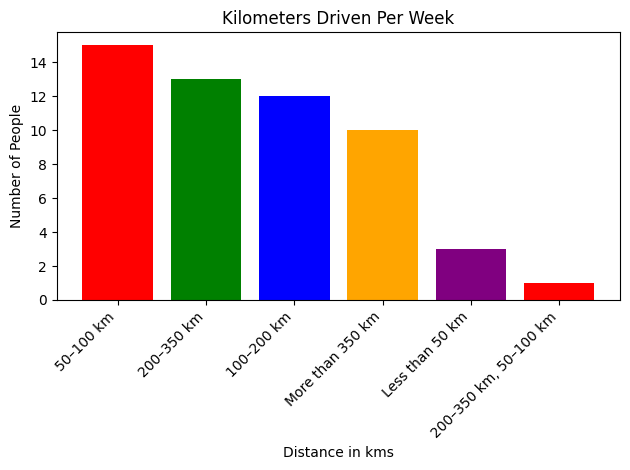

In [ ]:

# it's clear from the bar graph that we have 2 values for one of the collected data
counts = df['2.Approximately how many kilometers do you drive in a typical week?'].value_counts()
plt.bar(counts.index, counts.values, color=['red','green','blue','orange','purple'])
plt.title('Kilometers Driven Per Week')
plt.xlabel('Distance in kms')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('counts.png')
plt.show()

In [ ]:
# we decided to drop the row
# we check we have the correct row before dropping it after reviewing the dataset file
print(df.loc[15])

Timestamp                                                                                                                                 4/6/2026 20:13:02
Gender                                                                                                                                               Female
Age group                                                                                                                                             18-20
1.Which fuel grade do you most commonly use?                                                                                                     Benzeen 92
2.Approximately how many kilometers do you drive in a typical week?                                                                   200–350 km, 50–100 km
3. Roughly how much do you spend on fuel per month?                                                                                                   800.0
4.How much of a financial burden do you consider current fuel pr

In [ ]:
df.drop(15, inplace=True)

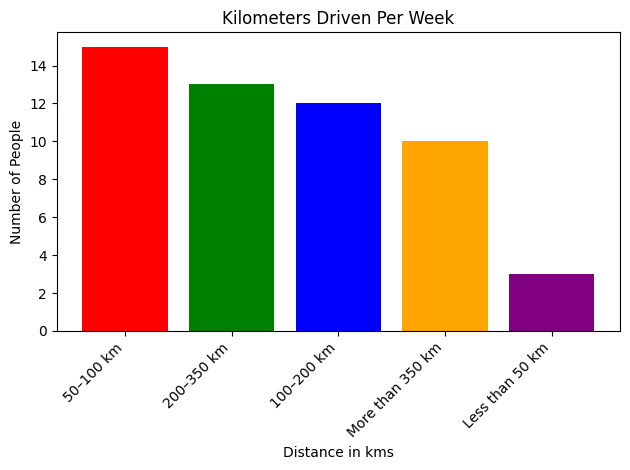

In [ ]:
#run again the bar chart
counts = df['2.Approximately how many kilometers do you drive in a typical week?'].value_counts()
plt.bar(counts.index, counts.values, color=['red','green','blue','orange','purple'])
plt.title('Kilometers Driven Per Week')
plt.xlabel('Distance in kms')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('counts.png')
plt.show()

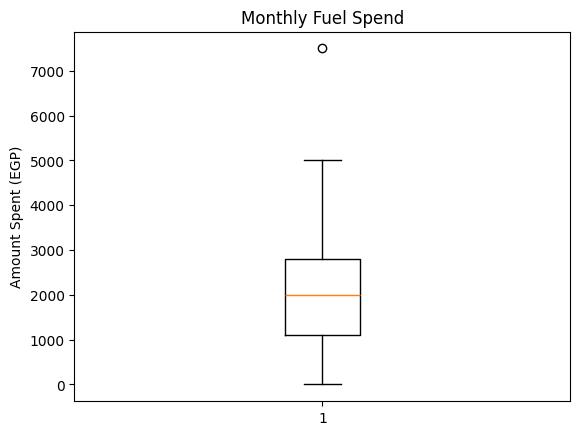

In [ ]:
# identify the quartiers along with the outliers
plt.boxplot(df['3. Roughly how much do you spend on fuel per month?'])
plt.title('Monthly Fuel Spend')
plt.ylabel('Amount Spent (EGP)')
plt.savefig('boxplot.png')
plt.show()

In [8]:
# calculated the mean, mode, median
fuel_spending = df["3. Roughly how much do you spend on fuel per month?"]
print("Mean fuel spending:", fuel_spending.mean())
print("Median fuel spending:", fuel_spending.median())
print("Mode fuel spending:", fuel_spending.mode()[0])

Mean fuel spending: 2082.816326530612
Median fuel spending: 2000.0
Mode fuel spending: 2000.0


In [10]:
burden = df['4.How much of a financial burden do you consider current fuel prices to be? (1 = no burden at all, 5 = very significant burden)']

print("Mean burden rating:", burden.mean())
print("Median burden rating:", burden.median())
print("Mode burden rating:", burden.mode()[0])

Mean burden rating: 3.685185185185185
Median burden rating: 3.5
Mode burden rating: 3


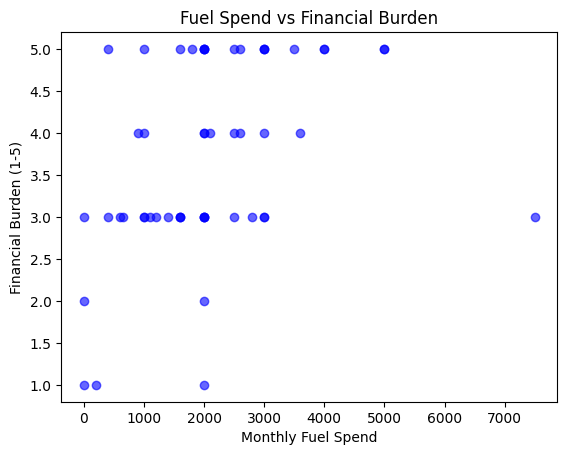

In [ ]:
# is the feeling of financial burden dependant of the monthly fuel spend
plt.scatter(df['3. Roughly how much do you spend on fuel per month?'], df['4.How much of a financial burden do you consider current fuel prices to be? (1 = no burden at all, 5 = very significant burden)'], color='blue',alpha=0.6)
plt.xlabel('Monthly Fuel Spend')
plt.ylabel('Financial Burden (1-5)')
plt.title('Fuel Spend vs Financial Burden')
plt.savefig('scatter.png')
plt.show()

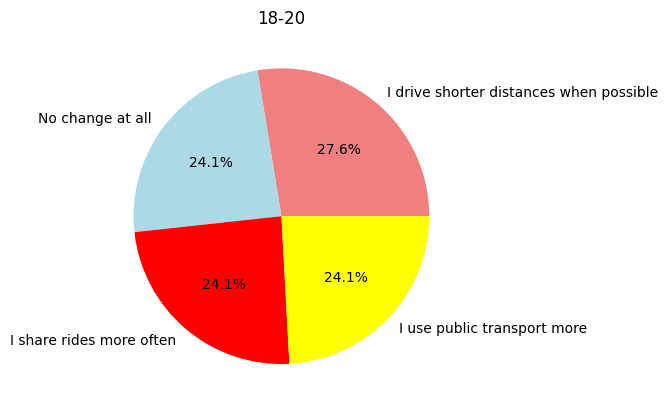

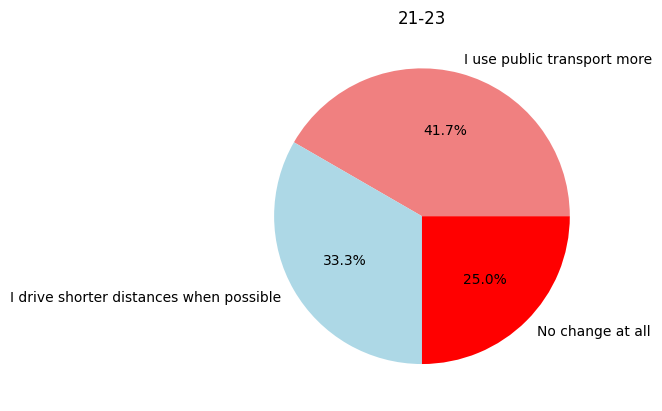

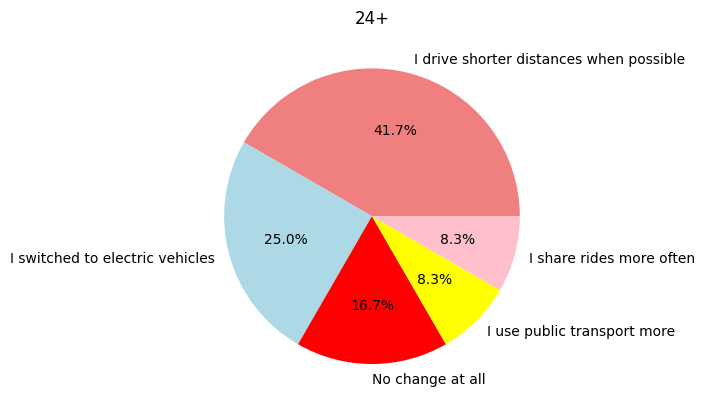

In [ ]:
# does age affect driving habits?

first_counts = df[df['Age group'] == '18-20']['5.Have recent fuel price increases in Egypt changed any of your driving habits?'].value_counts()
plt.pie(first_counts, labels=first_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'red', 'yellow','pink'])
plt.title('18-20')
plt.savefig('18-20.png')
plt.show()

second_counts = df[df['Age group'] == '21-23']['5.Have recent fuel price increases in Egypt changed any of your driving habits?'].value_counts()
plt.pie(second_counts, labels=second_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'red', 'yellow','pink'])
plt.title('21-23')
plt.savefig('21-23.png')
plt.show()

third_counts = df[df['Age group'] == '24+']['5.Have recent fuel price increases in Egypt changed any of your driving habits?'].value_counts()
plt.pie(third_counts, labels=third_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'red', 'yellow','pink'])
plt.title('24+')
plt.savefig('24+.png')
plt.show()